In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

In [2]:
os.chdir(Path().resolve().parent)

con = duckdb.connect('notebooks/credit_risk.db')
df = con.execute("SELECT * FROM mart.features").df()

In [3]:
print(df.describe())

         is_default     loan_amnt   installment    annual_inc           dti  \
count  1.341110e+06  1.341110e+06  1.341110e+06  1.341110e+06  1.341110e+06   
mean   1.996659e-01  1.439484e+04  4.372950e+02  7.501837e+04  1.815417e+01   
min    0.000000e+00  5.000000e+02  4.930000e+00  6.000000e+02 -1.000000e+00   
25%    0.000000e+00  7.975000e+03  2.483000e+02  4.600000e+04  1.181000e+01   
50%    0.000000e+00  1.200000e+04  3.747500e+02  6.500000e+04  1.762000e+01   
75%    0.000000e+00  2.000000e+04  5.787900e+02  9.000000e+04  2.404000e+01   
max    1.000000e+00  4.000000e+04  1.719830e+03  4.999920e+05  5.998000e+01   
std    3.997494e-01  8.697600e+03  2.608214e+02  4.506488e+04  8.511889e+00   

           fico_avg      open_acc    revol_util     total_acc  loan_to_income  \
count  1.341110e+06  1.341110e+06  1.340262e+06  1.341110e+06    1.341110e+06   
mean   6.981572e+02  1.159003e+01  5.180771e+01  2.497229e+01    2.146261e-01   
min    6.270000e+02  0.000000e+00  0.000000e+

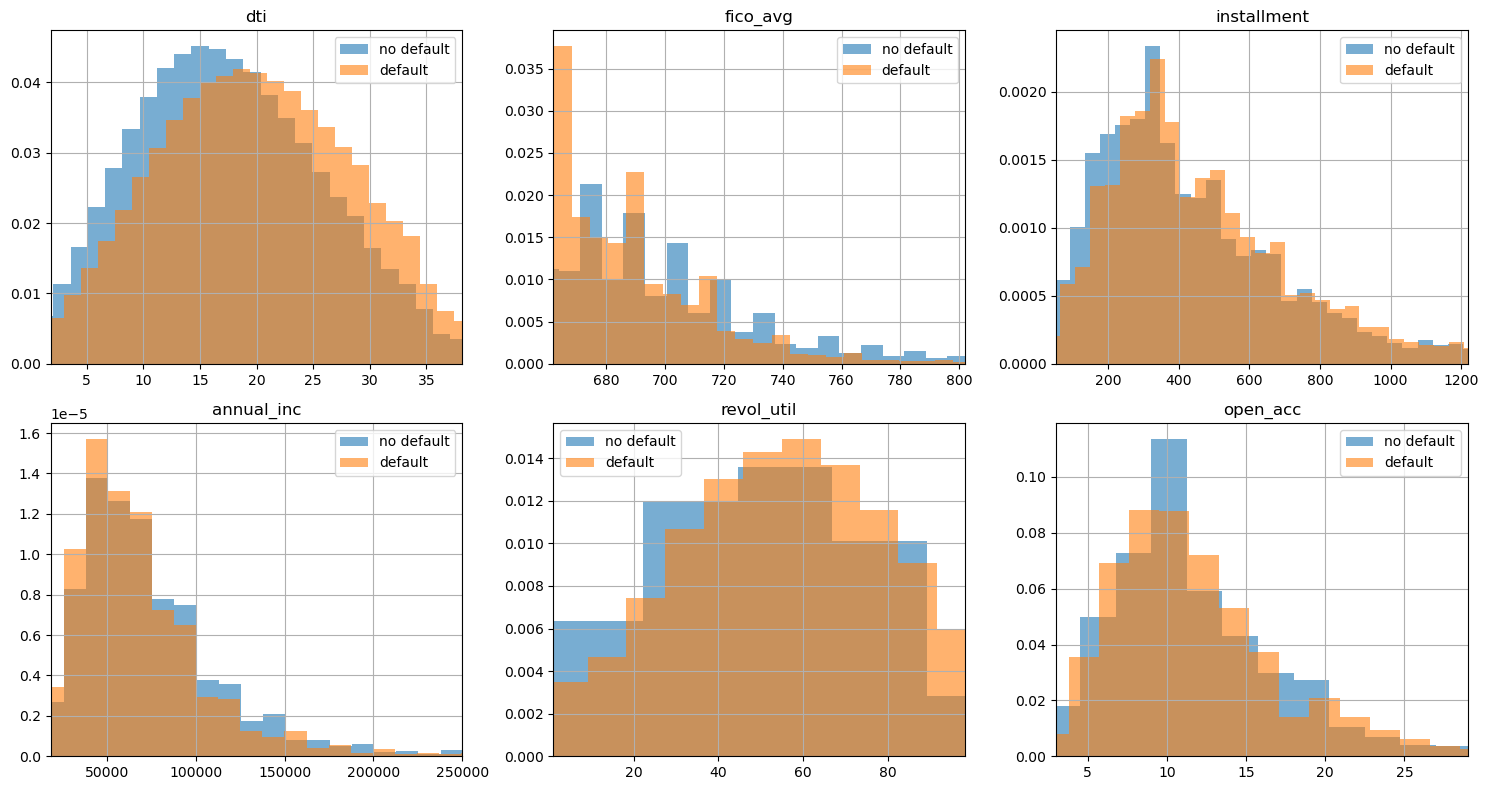

In [4]:
# Распределение PD по ключевым предикторам
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['dti', 'fico_avg',
            'installment', 'annual_inc', 'revol_util','open_acc']
ax = axes.flat

def graph(feat,ax,nbins):
    xmax = df[feat].quantile(0.99)
    xmin = df[feat].quantile(0.01)
    df.groupby('is_default')[feat].hist(
        bins=nbins, alpha=0.6, ax=ax, density=True
    )
    ax.set_xlim(xmin, xmax)
    ax.set_title(feat)
    ax.legend(['no default', 'default'])


graph(features[0],ax[0],40)
graph(features[1],ax[1],30)
graph(features[2],ax[2],40)
graph(features[3],ax[3],40)
graph(features[4],ax[4],40)
graph(features[5],ax[5],40)

plt.tight_layout()
plt.show()

In [5]:
pd.set_option('display.float_format', '{:.4f}'.format)
# 3. Дефолтность по категориям
for col in ['home_ownership', 'purpose', 'term_months']:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)['is_default']
        .agg(['mean', 'count'])
        .sort_values('mean', ascending=False)
        .round(3)
    )

# 4. Корреляция с дефолтностью
print("\nКорреляция предикторов с is_default:")
print(
    df[features + ['is_default'] + ['term_months']]
    .corr()['is_default']
    .sort_values(ascending=False)
    .round(3)
)


--- home_ownership ---
                 mean   count
home_ownership               
RENT           0.2320  533496
OWN            0.2060  144357
ANY            0.1960     286
OTHER          0.1890     143
MORTGAGE       0.1720  662781
NONE           0.1490      47

--- purpose ---
                     mean   count
purpose                          
small_business     0.2970   15329
renewable_energy   0.2380     929
moving             0.2340    9447
house              0.2200    7222
medical            0.2180   15507
debt_consolidation 0.2110  778083
other              0.2100   77589
vacation           0.1920    9048
major_purchase     0.1860   29317
home_improvement   0.1780   86962
educational        0.1720     326
credit_card        0.1690  294507
car                0.1470   14555
wedding            0.1220    2289

--- term_months ---
              mean    count
term_months                
60          0.3250   323369
36          0.1600  1017741

Корреляция предикторов с is_default:
is_d

In [6]:
con.close()